
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [1]:
from Controller import*
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-08-13  weekday:  3  day:  Thursday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


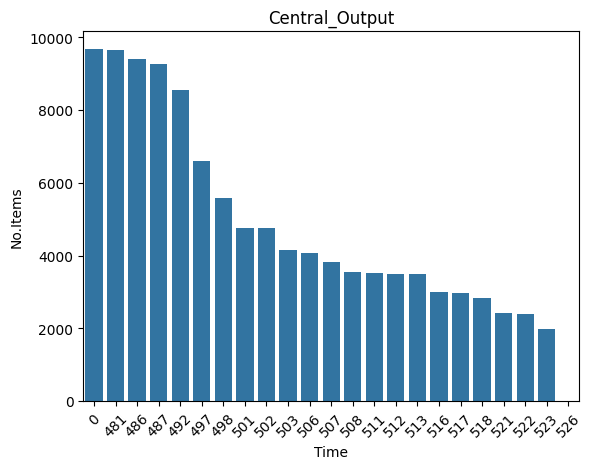

,BufferName,Time,No.Items
0,Central_Output,0,9673
1,Central_Output,481,9648
2,Central_Output,486,9409
3,Central_Output,487,9251
4,Central_Output,492,8549
5,Central_Output,497,6596
6,Central_Output,498,5581
7,Central_Output,501,4761
8,Central_Output,502,4760
9,Central_Output,503,4160


______________________________


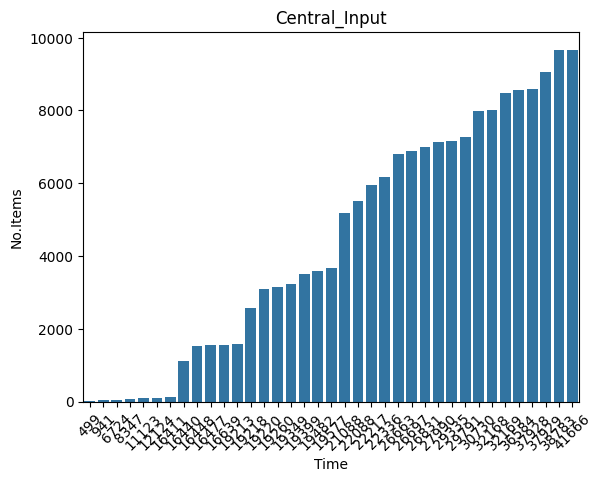

,BufferName,Time,No.Items
0,Central_Input,499,15
1,Central_Input,941,40
2,Central_Input,6724,50
3,Central_Input,8347,80
4,Central_Input,11123,97
5,Central_Input,12124,98
6,Central_Input,16411,122
7,Central_Input,16440,1101
8,Central_Input,16448,1521
9,Central_Input,16477,1541


______________________________


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

exec_df = pd.read_csv("EventExecutionData.csv")


for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    if start != end:
        display(sub_df)
    
        print("______________________________")

print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv("BufferData.csv")

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [ ]:
import pandas as pd

location_df = pd.read_csv("LocationData.csv")

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    